# 04 - Flat Index

---

In the previous notebook, we learned K-Nearest Neighbor (KNN).

KNN compares a query with every vector and returns the nearest neighbors.

A Flat Index follows exactly the same idea.

It stores all vectors and performs a brute-force search.

Although simple, Flat Index is the foundation for understanding every other vector index.

##  History

The earliest vector search systems used brute-force search.

Every query was compared against every stored vector.

This guaranteed the correct answer.

Later, this approach became known as the **Flat Index**.

Modern libraries such as FAISS still provide Flat Index implementations because they are exact and useful as a baseline.

##  Think Like a Researcher

Suppose your database contains only

100 vectors.

Should you build a complex search algorithm?

Probably not.

The easiest solution is:

Store every vector.

When a query arrives,

compare it with every vector.

Return the closest ones.

Simple.

Correct.

Easy to implement.

In [3]:
import numpy as np

documents = [
    "AI",
    "Machine Learning",
    "Deep Learning",
    "Football",
    "Basketball",
    "Cricket"
]

vectors = np.array([
    [1.0,1.1],
    [1.2,1.0],
    [0.9,0.8],
    [5.2,5.3],
    [5.5,5.6],
    [5.1,5.0]
])

query = np.array([1.05,1.0])

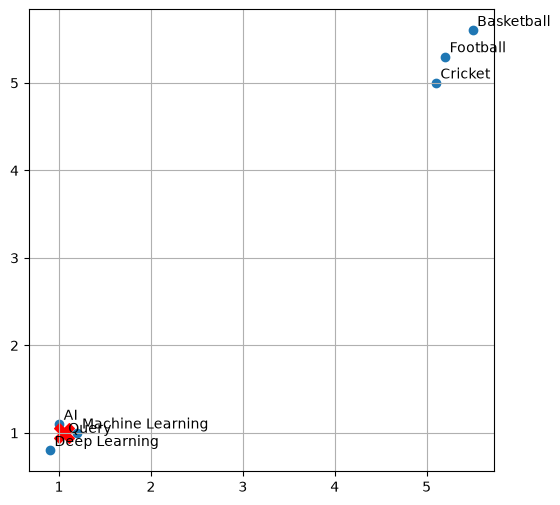

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(vectors[:,0],vectors[:,1])

for label,point in zip(documents,vectors):
    plt.text(point[0]+0.05,point[1]+0.05,label)

plt.scatter(
    query[0],
    query[1],
    marker="X",
    s=200,
    color="red"
)

plt.text(query[0]+0.05,query[1],"Query")

plt.grid()

plt.show()

In [5]:
#Flat Search
def euclidean(a,b):
    return np.sqrt(np.sum((a-b)**2))

results=[]

for doc,vector in zip(documents,vectors):

    distance = euclidean(query,vector)

    results.append((doc,distance))

results

[('AI', np.float64(0.11180339887498958)),
 ('Machine Learning', np.float64(0.1499999999999999)),
 ('Deep Learning', np.float64(0.24999999999999997)),
 ('Football', np.float64(5.975993641228211)),
 ('Basketball', np.float64(6.400195309519859)),
 ('Cricket', np.float64(5.6923193866823745))]

In [6]:
results = sorted(
    results,
    key=lambda x:x[1]
)

results

[('AI', np.float64(0.11180339887498958)),
 ('Machine Learning', np.float64(0.1499999999999999)),
 ('Deep Learning', np.float64(0.24999999999999997)),
 ('Cricket', np.float64(5.6923193866823745)),
 ('Football', np.float64(5.975993641228211)),
 ('Basketball', np.float64(6.400195309519859))]

In [7]:
k=3

results[:k]

[('AI', np.float64(0.11180339887498958)),
 ('Machine Learning', np.float64(0.1499999999999999)),
 ('Deep Learning', np.float64(0.24999999999999997))]

## Observation

Notice what happened.

The query was compared with

every stored vector.

Nothing was skipped.

This is exactly how Flat Index works.

In [8]:
import faiss

dimension = 2

index = faiss.IndexFlatL2(dimension)

index.add(
    vectors.astype("float32")
)

distance,indexes = index.search(
    np.array([query],dtype="float32"),
    3
)

indexes

array([[0, 1, 2]])

In [9]:
for i,d in zip(indexes[0],distance[0]):
    print(documents[i],d)

AI 0.012499999
Machine Learning 0.022500029
Deep Learning 0.06249999


## Internal Working

```
Store Vectors

↓

Query Arrives

↓

Compare with Vector 1

↓

Compare with Vector 2

↓

Compare with Vector 3

↓

...

↓

Compare with Vector N

↓

Sort

↓

Return Top K
```

## Time Complexity

Suppose

N = number of vectors

Every query

↓

N comparisons

Time Complexity

O(N)

As N increases,

search time also increases.

## Advantages

✅ Exact Search

✅ Simple

✅ No training

✅ Easy implementation

✅ Highest recall

## Limitations

❌ Slow on millions of vectors

❌ Every vector must be checked

❌ Doesn't scale well

Researchers wanted something faster.

## Real Uses

Flat Index is useful when

- Dataset is small
- Benchmarking ANN algorithms
- Testing retrieval quality
- Evaluating recall

##  Summary

Today I learned

- What Flat Index is
- How it works
- Why it is exact
- Why it becomes slow
- Why it is still useful

##  Think Like a Researcher

Flat Index guarantees the correct answer.

But there is a serious problem.

Suppose your vector database stores

1 billion vectors.

Should we still compare

every vector?

Probably not.

Researchers realized that finding an answer that is **almost always correct** could be much faster than finding the exact answer.

This idea led to **Approximate Nearest Neighbor (ANN)** algorithms.